In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## API Key Setup

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

if OPENROUTER_API_KEY:
    print("API Key Successfully loaded..")
else:
    print("API key not found")

API Key Successfully loaded..


In [5]:
from openai import OpenAI

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

print("OpenRouter client initialized successfully.")

OpenRouter client initialized successfully.


In [7]:
#model_name = "mistralai/mistral-7b-instruct"
#model_name = "stepfun/step-3.5-flash:free"
#model_name = "openai/gpt-oss-120b"
#model_name = "openai/gpt-oss-20b:free"
#model_name = "google/gemini-3.1-pro-preview"
model_name = "upstage/solar-pro-3:free"
print(f"Selected model: {model_name}")

Selected model: upstage/solar-pro-3:free


In [11]:
df = pd.read_csv(r"C:\Users\adity\DS_Projects\Prompt_Engineering_for_DataScience\data\telecom_churn_dataset 1.csv", on_bad_lines='skip')
df

,customer_id,age,income,tenure_months,monthly_charges,contract_type,payment_method,total_calls,data_usage_gb,num_products,complaint_registered,churn
0,CUST000001,60.0,20000,72,31.83,One-Year,Bank Transfer,4,4.09,3,No,0
1,CUST000002,98.0,81309,-5,NaN,Two-Year,Credit Card,43,27.65,2,No,1
2,CUST000003,63.0,35K,58,72.41,Two-Year,Electronic Check,2,59.42,5,No,0
3,CUST000004,32.0,$53259,58,69.17,One-Year,Bank Transfer,5,38.60,5,No,0
4,CUST000006,NaN,40K,67,72.67,Two-Year,Credit Card,5,6.49,1,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3808,CUST004996,95.0,NaN,6,97.06,Two-Year,Electronic Check,8,13.42,4,No,0
3809,CUST004997,37.0,$50202,64,61.49,One-Year,Credit Card,3,54.29,3,No,0
3810,CUST004998,45.0,73497,43,43.51,Two-Year,Credit Card,3,10.41,1,No,0
3811,CUST004999,51.0,$37961,9,94.35,Month-to-Month,Bank Transfer,1,19.02,1,No,1


In [18]:
missings_values=df.isnull().sum()

In [20]:
data_info=df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3813 entries, 0 to 3812
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           3813 non-null   object 
 1   age                   3282 non-null   float64
 2   income                3423 non-null   object 
 3   tenure_months         3813 non-null   int64  
 4   monthly_charges       3525 non-null   float64
 5   contract_type         3813 non-null   object 
 6   payment_method        3813 non-null   object 
 7   total_calls           3813 non-null   int64  
 8   data_usage_gb         3813 non-null   float64
 9   num_products          3813 non-null   int64  
 10  complaint_registered  3813 non-null   object 
 11  churn                 3813 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 357.6+ KB


In [22]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

outliers = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers[col] = int(((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum())

In [30]:
duplicates = df.duplicated().sum()

In [34]:
skewness = df[numeric_cols].skew().to_dict()

In [44]:
summary = {
    "shape": df.shape,
    "columns": df.columns.tolist(),
    "dtypes": df.dtypes.astype(str).to_dict(),
    "missing_values": df.isnull().sum().to_dict(),
    "describe": df.describe().to_dict(),
    "outliers": outliers,
    "duplicates": int(duplicates),
    "skewness": skewness
}


In [46]:
prompt_text = f"""  You are a Senior Data Scientist,\
Perform a basic data analysis on the Telecom churn dataset, \
identifying key features and potential insights. The data is represented \
by the `df` variable.

{summary}

read the missing values `df` and suggest how to handle this dataset whether should i drop or fill missing values,\
Tell us which features are not important to predict churn and which features are need to drop ,\
Give the summary analysis in Markdown format."""

try:
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "user", "content": prompt_text}
        ],
        temperature=0.7
    )

    model_response_content = response.choices[0].message.content
    print("\n--- Model's Data Analysis Report ---")
    print(model_response_content)
except Exception as e:
    print(f"An error occurred: {e}")


--- Model's Data Analysis Report ---
## 📊 Telecom Churn – Quick Exploratory & Feature‑Engineering Summary  

Below is a concise, markdown‑formatted analysis of the **`df`** you provided. It covers:

1. **Missing‑value overview** – how many & why they matter.  
2. **Imputation vs. dropping** – practical recommendations.  
3. **Feature importance** – which columns are likely to drive churn and which can be safely dropped.  
4. **Outlier & distribution considerations** – skewness & extreme values.  
5. **Next‑step preprocessing checklist**.

---

### 1️⃣ Data Overview  

| Column                | Type       | Missing % | Observations (count) | Key stats (mean / median) |
|-----------------------|------------|----------|----------------------|--------------------------|
| **customer_id**       | object     | 0%       | 3 813                | –                        |
| **age**               | float64    | 13.9%    | 3 282                | mean ≈ 43 yr, median ≈ 42 |
| **income**         

In [48]:

def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute missing values:
    - Numerical columns → median
    - Categorical columns → mode
    """

    df = df.copy()

    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(exclude=np.number).columns

    # Numerical → median
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

    # Categorical → mode
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)

    return df

In [50]:
def remove_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove outliers from numerical columns using IQR method.
    """

    df = df.copy()

    num_cols = df.select_dtypes(include=np.number).columns

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

In [52]:
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Full cleaning pipeline:
    1. Impute missing values
    2. Remove outliers
    """

    df = impute_missing_values(df)
    df = remove_outliers_iqr(df)

    return df

In [62]:
df_clean = clean_dataframe(df)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (3813, 12)
Cleaned shape: (3316, 12)


In [66]:
df_clean.isnull().sum()

customer_id             0
age                     0
income                  0
tenure_months           0
monthly_charges         0
contract_type           0
payment_method          0
total_calls             0
data_usage_gb           0
num_products            0
complaint_registered    0
churn                   0
dtype: int64

In [70]:
skewness1 = df_clean[numeric_cols].skew().to_dict()

In [72]:
cleaned_outliers = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    cleaned_outliers[col] = int(((df_clean[col] < (Q1 - 1.5 * IQR)) | (df_clean[col] > (Q3 + 1.5 * IQR))).sum())

In [74]:
cleaned_summary = {
    "shape": df_clean.shape,
    "columns": df_clean.columns.tolist(),
    "dtypes": df_clean.dtypes.astype(str).to_dict(),
    "missing_values": df_clean.isnull().sum().to_dict(),
    "describe": df_clean.describe().to_dict(),
    "outliers": cleaned_outliers,
    "duplicates": int(duplicates),
    "skewness": skewness1
}

In [76]:
cleaned_summary

{'shape': (3316, 12),
 'columns': ['customer_id',
  'age',
  'income',
  'tenure_months',
  'monthly_charges',
  'contract_type',
  'payment_method',
  'total_calls',
  'data_usage_gb',
  'num_products',
  'complaint_registered',
  'churn'],
 'dtypes': {'customer_id': 'object',
  'age': 'float64',
  'income': 'object',
  'tenure_months': 'int64',
  'monthly_charges': 'float64',
  'contract_type': 'object',
  'payment_method': 'object',
  'total_calls': 'int64',
  'data_usage_gb': 'float64',
  'num_products': 'int64',
  'complaint_registered': 'object',
  'churn': 'int64'},
 'missing_values': {'customer_id': 0,
  'age': 0,
  'income': 0,
  'tenure_months': 0,
  'monthly_charges': 0,
  'contract_type': 0,
  'payment_method': 0,
  'total_calls': 0,
  'data_usage_gb': 0,
  'num_products': 0,
  'complaint_registered': 0,
  'churn': 0},
 'describe': {'age': {'count': 3316.0,
   'mean': 41.60162846803377,
   'std': 12.657392229093212,
   'min': 12.0,
   '25%': 33.0,
   '50%': 42.0,
   '75%': 

In [80]:
analysis_prompt = f"""  You are a Senior Data Scientist,\
Perform a basic data analysis on the Telecom dataset, \
identifying key features and potential insights. The data is represented \
by the `df` variable.

{cleaned_summary}


Tell us which features are not important to predict churn and which features are need to drop ,\
Provide a summary of the dataset, including numerical and categorical features, \
any initial observations about distributions, and potential relationships between variables, \
especially focusing on 'churn' as the target variable,\
Give the summary analysis in Markdown format."""

try:
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "user", "content": analysis_prompt}
        ],
        temperature=0.7
    )

    model_response_content1 = response.choices[0].message.content
    print("\n--- Model's Data Analysis Report ---")
    print(model_response_content1)
except Exception as e:
    print(f"An error occurred: {e}")


--- Model's Data Analysis Report ---
# 📊 Telecom Dataset – Quick Exploratory Summary  

*(All observations are based on the metadata you supplied for the `df` DataFrame.)*  

---

## 1️⃣ Overview  

| Item | Details |
|------|---------|
| **Rows / Columns** | 3 316 rows × 12 columns |
| **Target variable** | `churn` (binary 0 = stay, 1 = leave) |
| **Missing values** | **0** in every column – no imputation needed |
| **Duplicates** | **0** – the data set is clean in that respect |
| **Overall balance** | `churn` mean ≈ 0.35 → ~35 % churn rate (moderately imbalanced) |

---

## 2️⃣ Data Types  

| Type | Columns |
|------|--------|
| **Numeric (continuous)** | `age`, `tenure_months`, `monthly_charges`, `total_calls`, `data_usage_gb`, `num_products`, `churn` |
| **Categorical (object)** | `customer_id` (unique identifier), `contract_type`, `payment_method`, `income`, `complaint_registered` |

> **Note:** `customer_id` is an identifier only – it carries no predictive signal.  
> `income`

In [ ]:
# with open("TelecomChurn_Analysis_report(solar-pro-3).md", "w", encoding="utf-8") as f:
#     f.write(model_response_content1)

In [102]:
z=df_clean.corr(numeric_only=True)
z

,age,tenure_months,monthly_charges,total_calls,data_usage_gb,num_products,churn
age,1.000000,-0.020182,-0.009738,0.002585,-0.000044,-0.000723,0.015595
tenure_months,-0.020182,1.000000,0.007988,0.012139,0.030878,0.019720,-0.060011
monthly_charges,-0.009738,0.007988,1.000000,0.058468,-0.002950,0.009797,0.002395
total_calls,0.002585,0.012139,0.058468,1.000000,-0.022910,-0.008933,-0.003917
data_usage_gb,-0.000044,0.030878,-0.002950,-0.022910,1.000000,0.041385,0.025160
num_products,-0.000723,0.019720,0.009797,-0.008933,0.041385,1.000000,0.025285
churn,0.015595,-0.060011,0.002395,-0.003917,0.025160,0.025285,1.000000


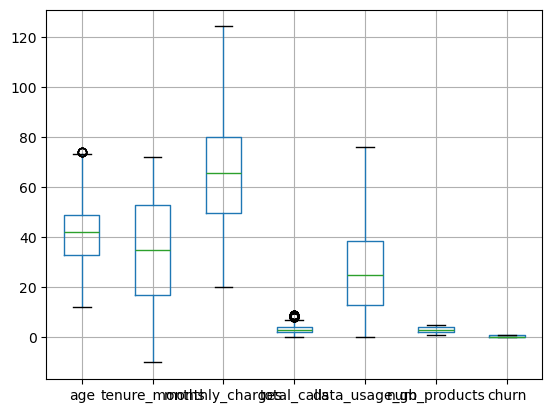

In [110]:
df_clean.boxplot()
plt.show()

In [114]:
cat_cols = df.select_dtypes(include="object").columns

In [116]:
cat_cols.isnull().sum()

0

## Label Encoding

In [118]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

In [120]:
df_clean

,customer_id,age,income,tenure_months,monthly_charges,contract_type,payment_method,total_calls,data_usage_gb,num_products,complaint_registered,churn
0,0,60.0,926,72,31.83,1,0,4,4.09,3,0,0
2,1,63.0,1115,58,72.41,2,2,2,59.42,5,0,0
3,2,32.0,402,58,69.17,1,0,5,38.60,5,0,0
4,3,42.0,1207,67,72.67,2,1,5,6.49,1,1,0
5,4,42.0,107,66,65.51,2,2,3,12.62,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3806,3311,49.0,1522,64,83.17,1,0,3,11.16,5,0,0
3809,3312,37.0,359,64,61.49,1,1,3,54.29,3,0,0
3810,3313,45.0,1734,43,43.51,2,1,3,10.41,1,0,0
3811,3314,51.0,167,9,94.35,0,0,1,19.02,1,0,1


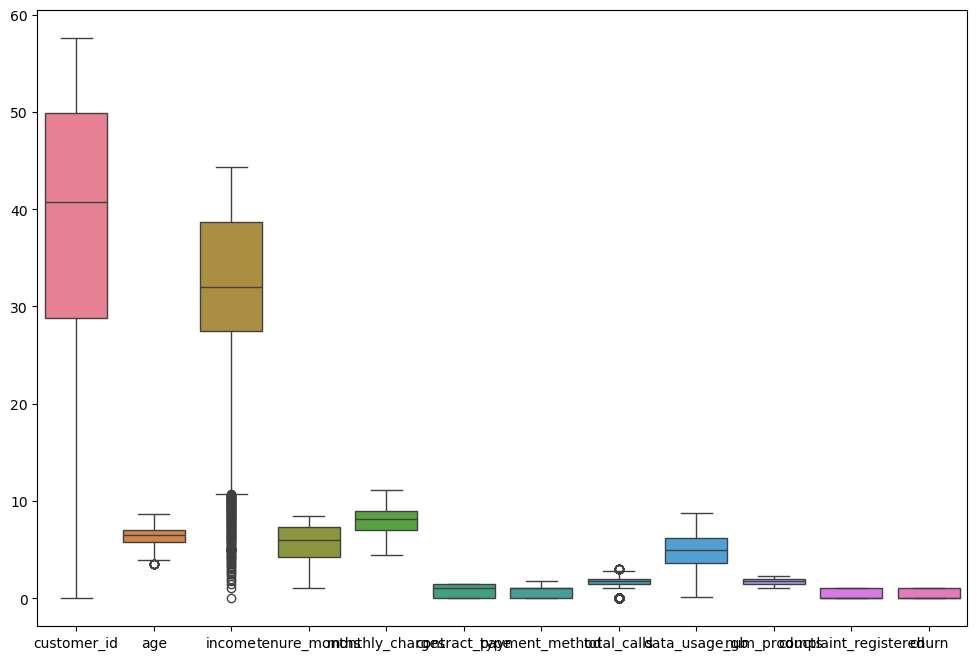

In [122]:
plt.figure(figsize=(12,8))
sns.boxplot(data=np.sqrt(df_clean))
plt.show()

In [126]:
Q1 = df_clean['income'].quantile(0.25)
Q3 = df_clean['income'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[(df_clean['income'] >= (Q1 - 1.5 * IQR)) & (df_clean['income'] <= (Q3 + 1.5 * IQR))]

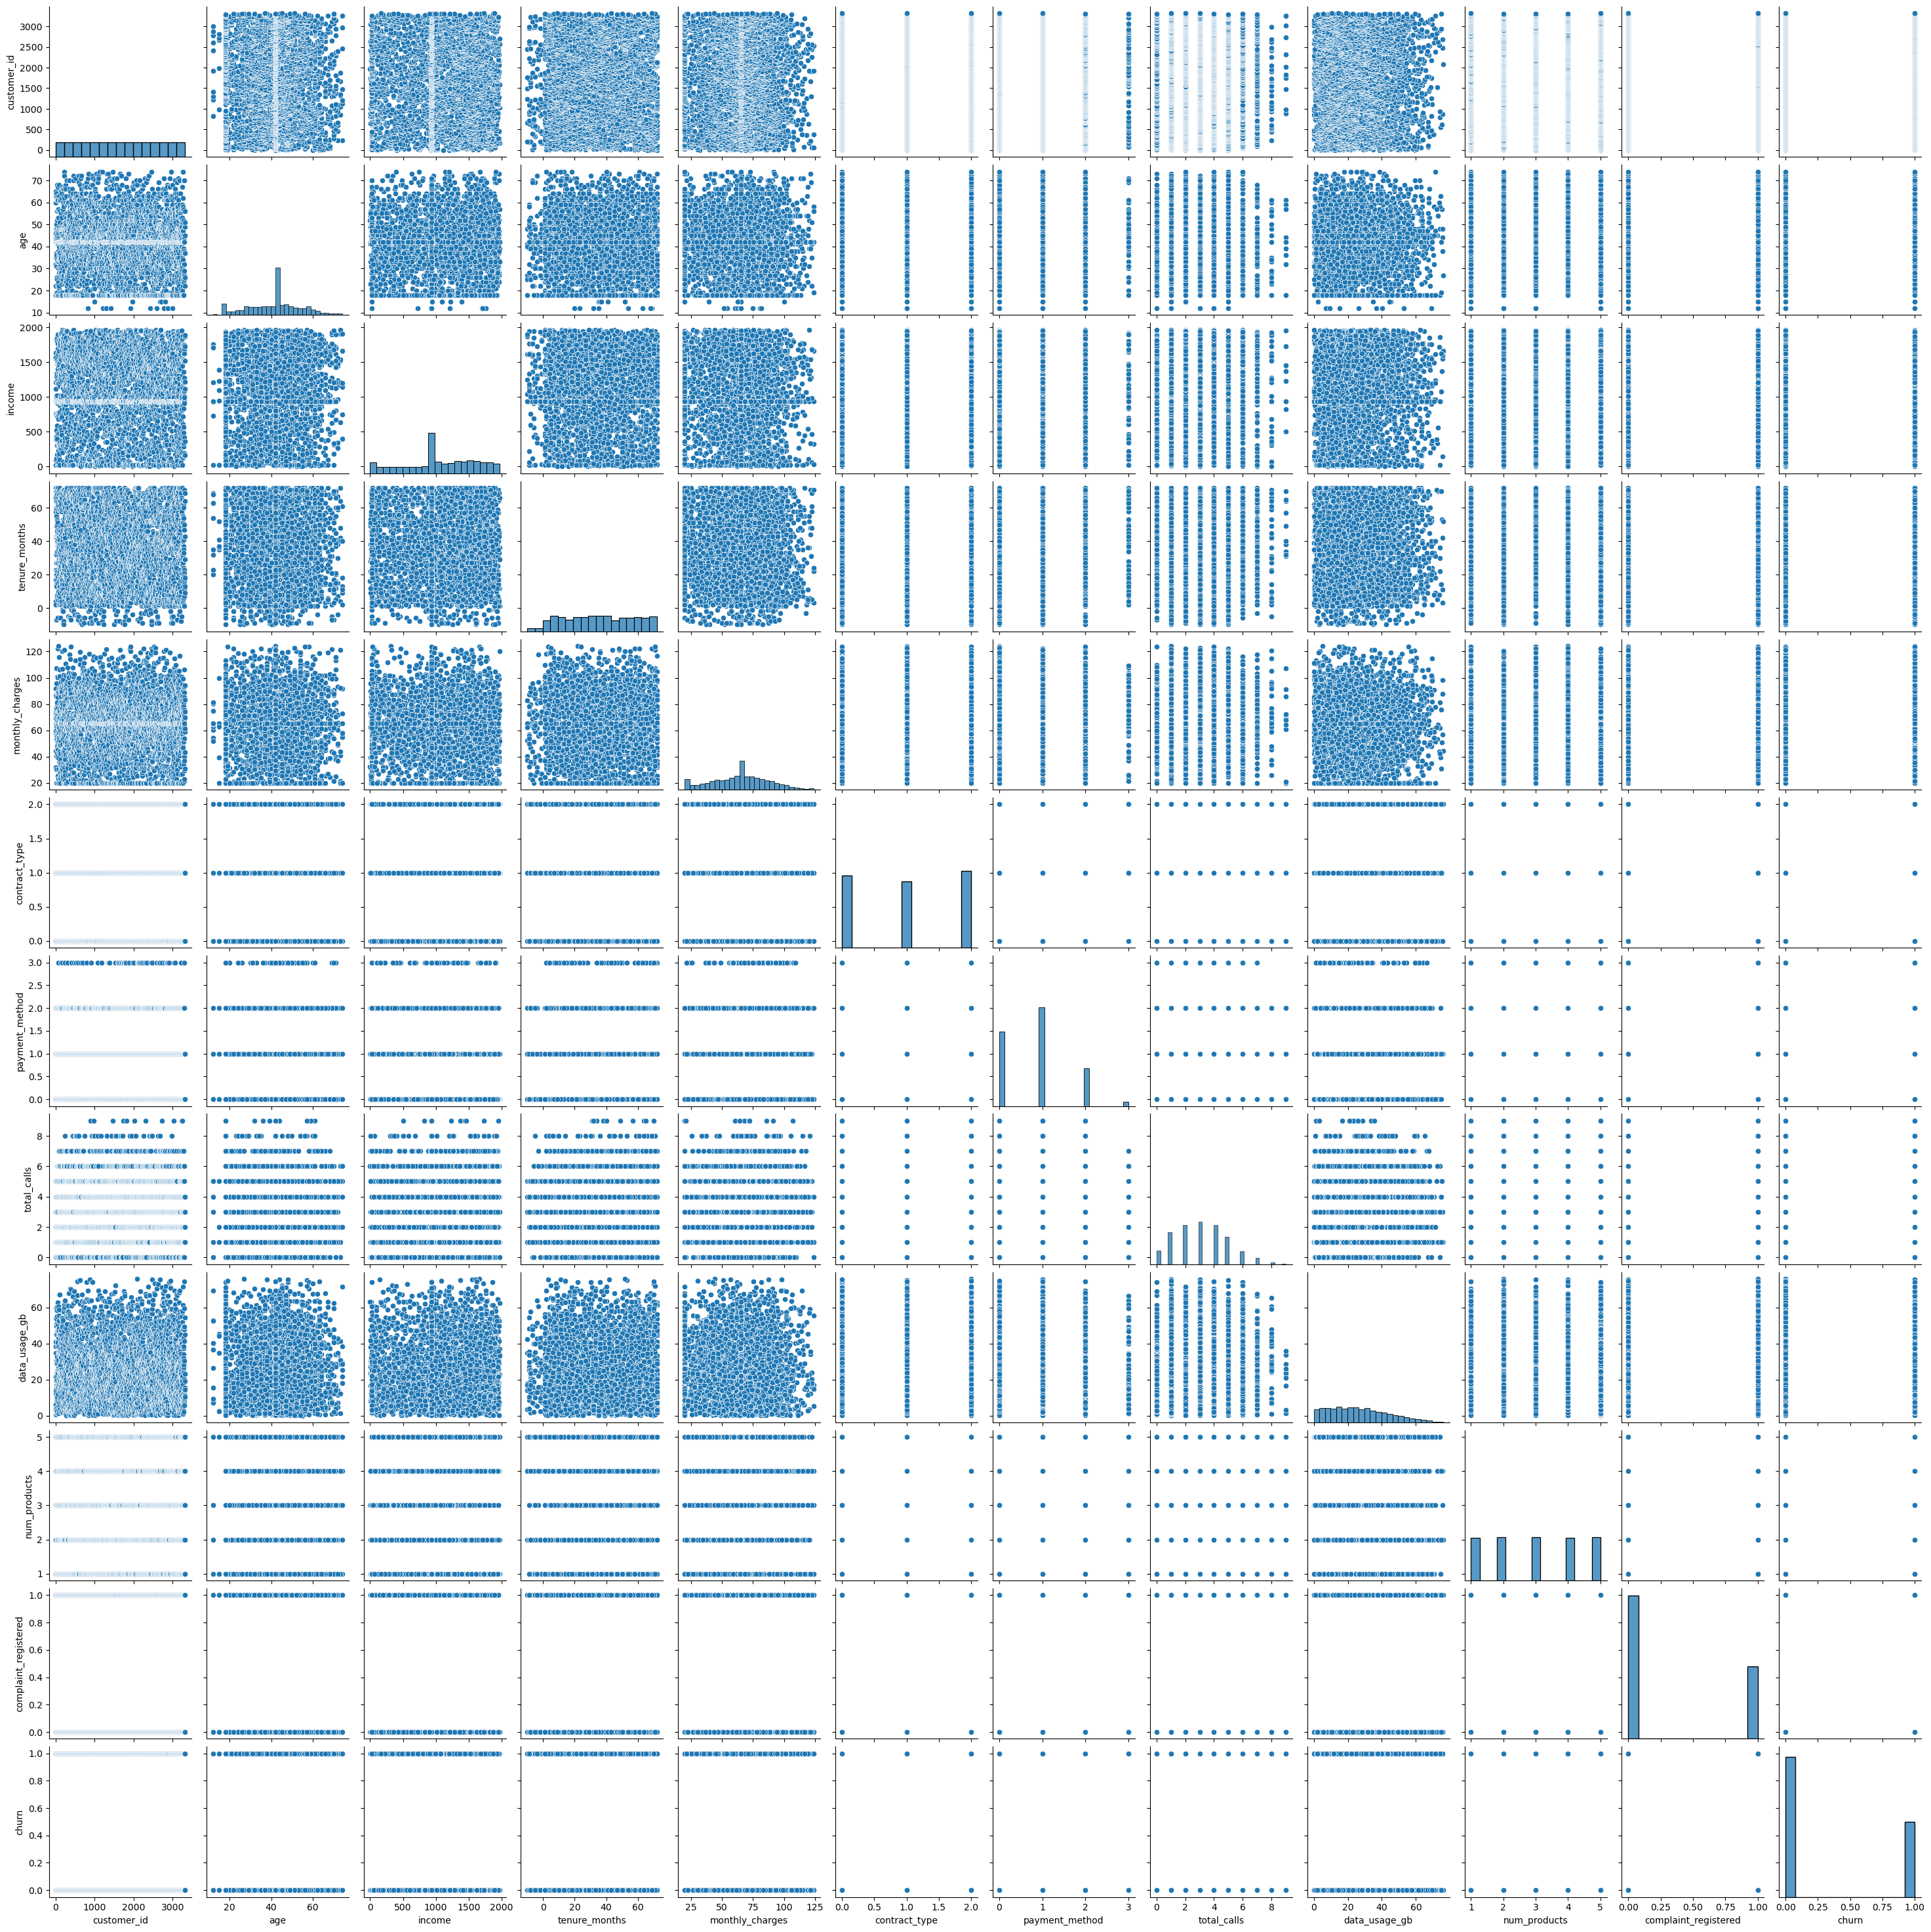

In [128]:
sns.pairplot(df_clean)
plt.show()

In [132]:
x = df_clean.drop(["churn", "customer_id"], axis=1)
x

,age,income,tenure_months,monthly_charges,contract_type,payment_method,total_calls,data_usage_gb,num_products,complaint_registered
0,60.0,926,72,31.83,1,0,4,4.09,3,0
2,63.0,1115,58,72.41,2,2,2,59.42,5,0
3,32.0,402,58,69.17,1,0,5,38.60,5,0
4,42.0,1207,67,72.67,2,1,5,6.49,1,1
5,42.0,107,66,65.51,2,2,3,12.62,5,1
...,...,...,...,...,...,...,...,...,...,...
3806,49.0,1522,64,83.17,1,0,3,11.16,5,0
3809,37.0,359,64,61.49,1,1,3,54.29,3,0
3810,45.0,1734,43,43.51,2,1,3,10.41,1,0
3811,51.0,167,9,94.35,0,0,1,19.02,1,0


In [134]:
y = df_clean["churn"]
y

0       0
2       0
3       0
4       0
5       0
       ..
3806    0
3809    0
3810    0
3811    1
3812    0
Name: churn, Length: 3316, dtype: int64

In [136]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

## Logistic Regression 

In [140]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train, y_train)

LogisticRegression()

In [142]:
log_pred = log_model.predict(x_test)

In [148]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
logistic_reg_accuracy=accuracy_score(y_test, log_pred)

In [150]:
logistic_reg_accuracy

0.6912650602409639

In [154]:
log_classification=classification_report(y_test,log_pred)

In [160]:
print(log_classification)

              precision    recall  f1-score   support

           0       0.70      0.91      0.79       424
           1       0.66      0.30      0.42       240

    accuracy                           0.69       664
   macro avg       0.68      0.61      0.60       664
weighted avg       0.68      0.69      0.65       664



In [164]:
log_confusion=confusion_matrix(y_test,log_pred)

In [166]:
log_confusion

array([[386,  38],
       [167,  73]], dtype=int64)

In [230]:
log_performance_before_tunig = {
    "Logistic Regression Accuracy before tuning" : logistic_reg_accuracy,
    "Logistic Regression Classification Report " : log_classification,
    "Logistic Regression Confusion Matrix " : log_confusion
}

{'Logistic Regression Accuracy before tuning': 0.6912650602409639, 'Logistic Regression Classification Report ': '              precision    recall  f1-score   support\n\n           0       0.70      0.91      0.79       424\n           1       0.66      0.30      0.42       240\n\n    accuracy                           0.69       664\n   macro avg       0.68      0.61      0.60       664\nweighted avg       0.68      0.69      0.65       664\n', 'Logistic Regression Confusion Matrix ': array([[386,  38],
       [167,  73]], dtype=int64)}


## Random Forest Classifier

In [169]:
from sklearn.ensemble import RandomForestClassifier
RF_model=RandomForestClassifier(random_state=1,n_jobs=-1,n_estimators=100,max_depth=5,oob_score=True)

In [171]:
RF_model.fit(x_train,y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=1)

In [173]:
RF_pred=RF_model.predict(x_test)
RF_pred

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [177]:
RF_Classification=classification_report(y_test, RF_pred)
print(RF_Classification)

              precision    recall  f1-score   support

           0       0.68      0.94      0.79       424
           1       0.67      0.22      0.33       240

    accuracy                           0.68       664
   macro avg       0.68      0.58      0.56       664
weighted avg       0.68      0.68      0.62       664



In [181]:
RF_accuracy=accuracy_score(y_test, RF_pred)

In [183]:
RF_confusion=confusion_matrix(y_test,RF_pred)
RF_confusion

array([[398,  26],
       [187,  53]], dtype=int64)

In [234]:
RF_performance_before_tunig = {
    "Random Forest Classifier Accuracy before tuning" : RF_accuracy,
    "Random Forest Classifier Classification Report " : RF_Classification,
    "Random Forest Classifier Confusion Matrix " : RF_confusion
}

## XGBoost Classifier

In [188]:
from xgboost import XGBClassifier

xgb_model=XGBClassifier()

In [190]:
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [192]:
xgb_pred=xgb_model.predict(x_test)
xgb_pred

array([0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,

In [196]:
XGB_confusion=confusion_matrix(y_test,xgb_pred)

In [198]:
XGB_classification=classification_report(y_test,xgb_pred)

In [200]:
XGB_accuracy=accuracy_score(y_test, xgb_pred)

In [236]:
XGB_performance_before_tunig = {
    "XGBoost Classifier Accuracy before tuning" : XGB_accuracy,
    "XGBoost Classifier Classification Report " : XGB_classification,
    "XGBoost Classifier Confusion Matrix " : XGB_confusion
}

## Model Comparision and accuarcy

In [203]:
print("\nModel Comparison:")
print("Logistic Regression:", logistic_reg_accuracy )
print("Random Forest:", RF_accuracy)
print("XGBoost:", XGB_accuracy)


Model Comparison:
Logistic Regression: 0.6912650602409639
Random Forest: 0.6792168674698795
XGBoost: 0.6596385542168675


In [205]:
model_comparison_before_tuning = {
    "Logistic Regression": logistic_reg_accuracy,
    "Random Forest": RF_accuracy,
    "XGBoost": XGB_accuracy
}

print(model_comparison_before_tuning)

{'Logistic Regression': 0.6912650602409639, 'Random Forest': 0.6792168674698795, 'XGBoost': 0.6596385542168675}


## Hyperparameter Tuning

In [208]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

In [210]:
# Logistic Regression Hyperparameter Tuning
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [1000, 2000]
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=lr_params,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(x_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression Params:", grid_lr.best_params_)

log_pred1 = best_lr.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}


In [212]:
from scipy.stats import randint

rf_params = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10),
    "bootstrap": [True, False]
}

rand_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=rf_params,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rand_rf.fit(x_train, y_train)

best_rf = rand_rf.best_estimator_
print("Best Random Forest Params:", rand_rf.best_params_)

RF_pred1 = best_rf.predict(x_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Params: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 108}


In [214]:
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(eval_metric="logloss"),
    param_grid=xgb_params,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(x_train, y_train)

best_xgb = grid_xgb.best_estimator_
print("Best XGBoost Params:", grid_xgb.best_params_)

xgb_pred1 = best_xgb.predict(x_test)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best XGBoost Params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [218]:
log_accuracy_tuned=accuracy_score(y_test, log_pred1)

In [220]:
RF_accuracy_tuned=accuracy_score(y_test, RF_pred1)

In [222]:
XGB_accuracy_tuned=accuracy_score(y_test, xgb_pred1)

In [215]:
print("\nModel Comparison After Tuning:")
print("Logistic Regression:", accuracy_score(y_test, log_pred1))
print("Random Forest:", accuracy_score(y_test, RF_pred1))
print("XGBoost:", accuracy_score(y_test, xgb_pred1))


Model Comparison After Tuning:
Logistic Regression: 0.6852409638554217
Random Forest: 0.677710843373494
XGBoost: 0.6927710843373494


In [226]:
model_comparison_after_tuning = {
    "Logistic Regression": log_accuracy_tuned,
    "Random Forest": RF_accuracy_tuned,
    "XGBoost": XGB_accuracy_tuned
}

print(model_comparison_after_tuning)

{'Logistic Regression': 0.6852409638554217, 'Random Forest': 0.677710843373494, 'XGBoost': 0.6927710843373494}


In [240]:
model_summary = {
    "Dataset Summary before cleaning": summary,
    "Dataset Cleaned Summary": analysis_prompt,
    "Model Accuracy Before Tuning": model_comparison_before_tuning,
    "Logistic Regression Performance Before Tuning" : log_performance_before_tunig,
    "Random Forest Classifier Performance Before Tuning " : RF_performance_before_tunig ,
    "XGBoost Classifier Performace Before Tuning " : XGB_performance_before_tunig,
    "Model Comparison After Tuning": model_comparison_after_tuning
}

In [242]:
model_prompt = f"""  You are a Senior Data Scientist performing a post-modeling analytical review.

You have already completed:
1. Raw data analysis → summary
2. Data cleaning & preprocessing analysis → cleaned_summary

Your current task is to analyze the model performance and feature behavior using:

model_summary

and compare it with the earlier dataset understanding.

======================
RAW DATA SUMMARY
{summary}

CLEANED DATA SUMMARY
{cleaned_summary}

MODEL SUMMARY
{model_summary}
======================

Your objectives:

write the final analysed report compared with summary, cleaned_summary, model_summary ,\
write the models performance before and after tuning ,\

 
1. Compare how preprocessing affected:
   - feature distributions
   - class balance
   - data quality
   - signal strength for predicting churn

2. Identify:
   - Features that consistently show low importance
   - Features that became useful after cleaning
   - Features that lost predictive power

3. Recommend:
   - Features to DROP (with reason)
   - Features to KEEP (with reason)
   - Features that may cause data leakage
   - Multicollinearity concerns
   - Potential interaction features

4. Interpret model behavior:
   - Which features are the strongest drivers of churn
   - Whether the model is relying on logical business signals
   - Any signs of overfitting or bias

5. Provide data science recommendations:
   - Feature engineering improvements
   - Encoding / scaling improvements
   - Model improvement strategies

Output Requirements:

Return a well-structured Markdown report with the following sections:

# 📊 Post-Model Data Analysis

## Dataset Evolution
## Key Predictive Features
## Features to Drop
## Data Leakage Risks
## Feature Engineering Opportunities
## Model Behavior Insights
## Business Interpretation
## Actionable Next Steps

Be precise, technical, and insight-driven.
Do not repeat basic statistics — focus on comparative and model-aware analysis.

write all the report in markdown format."""




try:
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "user", "content": model_prompt}
        ],
        temperature=0.7
    )

    model_response_content2 = response.choices[0].message.content
    print("\n--- Model's Data Analysis Report ---")
    print(model_response_content2)
except Exception as e:
    print(f"An error occurred: {e}")


--- Model's Data Analysis Report ---
# 📊 Post‑Model Data Analysis  

*Prepared by: Senior Data Scientist – Telecom Churn Prediction*  
*Date: 2026‑02‑23*  

---

## Dataset Evolution  

| Metric | **Raw (3813 rows)** | **Cleaned (3316 rows)** | **Impact on Modeling** |
|--------|-------------------|------------------------|------------------------|
| **Shape** | 3813 × 12 | 3316 × 12 | 497 rows removed – all rows with missing values in `age`, `income`, or `monthly_charges`. |
| **Missing values** | Age (531), Income (390), Monthly_charges (288) | **None** (0) | Guarantees that all downstream models receive complete rows; eliminates need for imputation or row‑wise masking. |
| **Target distribution** | `churn` mean = 0.371 (37 % churn) | `churn` mean = 0.3498 (35 % churn) | Slight shift toward a more balanced class ratio (still ~65 % non‑churn). Reduces class‑imbalance bias in evaluation metrics. |
| **Numeric feature means & stds** | Age µ=43.02 σ=15.90; Tenure µ=35.05 σ=21.58; Monthl

In [248]:
with open("Telecom_churn_report_final(solar-pro-3).md", "w", encoding="utf-8") as f:
    f.write(model_response_content2)